In [1]:
!pip install git+https://github.com/EdgeSimPy/EdgeSimPy.git gymnasium stable-baselines3 stable-baselines3[extra] networkx numpy pandas matplotlib torch

  Cloning https://github.com/EdgeSimPy/EdgeSimPy.git to /tmp/pip-req-build-153ekssp
  Running command git clone --filter=blob:none --quiet https://github.com/EdgeSimPy/EdgeSimPy.git /tmp/pip-req-build-153ekssp
  Resolved https://github.com/EdgeSimPy/EdgeSimPy.git to commit b4ad590d19b83f9327a0ba80b44560cdbb766919
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta

In [11]:
import gymnasium
import numpy as np
from edge_sim_py import Simulator
from edge_sim_py.components.edge_server import EdgeServer
from edge_sim_py.components.network_link import NetworkLink
from edge_sim_py.components.base_station import BaseStation
from edge_sim_py.components.network_switch import NetworkSwitch
from edge_sim_py.components.power_models.servers import LinearServerPowerModel
from edge_sim_py.components.service import Service
from edge_sim_py.components.application import Application
from edge_sim_py.components.container_image import ContainerImage
from edge_sim_py.components.user import User
from edge_sim_py.components import ContainerLayer, ContainerRegistry
from edge_sim_py.components.network_flow import NetworkFlow
from edge_sim_py.components.topology import Topology

class TaskOffloadingEnv(gymnasium.Env):
    def __init__(self, config=None):
      super().__init__()
      config = config or {}

      # Seeding
      self.np_random = None
      if "seed" in config:
          self.seed(config["seed"])
      else:
          self.seed()

      # Simulator setup
      self.simulator = Simulator(
          tick_duration=1,
          tick_unit="milliseconds",
          resource_management_algorithm=lambda parameters=None: None
      )

      # Dataset definition
      dataset = {
          "EdgeServer": [
              {"attributes": {"id": 1, "model_name": "EdgeDevice", "cpu": 1000, "memory": 4096, "disk": 102400},
              "relationships": {"power_model": "LinearServerPowerModel", "base_station": {"class": "BaseStation", "id": 1}}},
              {"attributes": {"id": 2, "model_name": "FogNode", "cpu": 4000, "memory": 16384, "disk": 512000},
              "relationships": {"power_model": "LinearServerPowerModel", "base_station": {"class": "BaseStation", "id": 2}}}
          ],
          "BaseStation": [
              {"attributes": {"id": 1}, "relationships": {"network_switch": {"class": "NetworkSwitch", "id": 1}}},
              {"attributes": {"id": 2}, "relationships": {"network_switch": {"class": "NetworkSwitch", "id": 1}}}
          ],
          "NetworkSwitch": [{"attributes": {"id": 1}, "relationships": {}}],
          "NetworkLink": [{"attributes": {"id": 1, "bandwidth": 100, "delay": 5},
                          "relationships": {"nodes": [{"class": "BaseStation", "id": 1}, {"class": "BaseStation", "id": 2}]}}],
          "ContainerImage": [{"attributes": {"digest": "dummy_image_digest", "name": "dummy_image", "layers_digests": []}, "relationships": {}}],
          "Application": [{"attributes": {"id": 1, "label": "task_offloading_app"}, "relationships": {}}]
      }

      for comp in ["User", "ContainerLayer", "ContainerRegistry", "NetworkFlow", "Topology", "Service"]:
          dataset.setdefault(comp, [])

      self.simulator.initialize(dataset)

      # Set power model parameters
      for server in EdgeServer.all():
          server.power_model = LinearServerPowerModel()
          if server.id == 1:
              server.power_model.power_per_unit_load = 0.5
              server.power_model.idle_power_consumption = 10
              server.power_model_parameters["static_power_percentage"] = 0.1
              server.power_model_parameters["max_power_consumption"] = 100
          else:
              server.power_model.power_per_unit_load = 0.7
              server.power_model.idle_power_consumption = 50
              server.power_model_parameters["static_power_percentage"] = 0.1
              server.power_model_parameters["max_power_consumption"] = 200

      # Spaces, references, counters
      self.action_space = gymnasium.spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
      self.observation_space = gymnasium.spaces.Dict({
          "edge_cpu_load": gymnasium.spaces.Box(0, 1, (1,), np.float32),
          "fog_cpu_load": gymnasium.spaces.Box(0, 1, (1,), np.float32),
          "task_cpu_demand": gymnasium.spaces.Box(0, 1, (1,), np.float32),
          "network_latency_to_fog": gymnasium.spaces.Box(0, 1, (1,), np.float32)
      })

      self.edge_device = EdgeServer.find_by_id(1)
      self.fog_node = EdgeServer.find_by_id(2)
      self.task_counter = 0
      self.current_task = None

      # Configurable parameters (with defaults)
      self.max_task_cpu_demand = config.get("max_task_cpu_demand", 500.0)
      self.max_network_latency = config.get("max_network_latency", 10.0)
      self.processing_duration_ticks = config.get("processing_duration_ticks", 10)
      self.w_latency = config.get("w_latency", 1.0)
      self.w_energy = config.get("w_energy", 0.5)
      self.max_steps_per_episode = config.get("max_steps_per_episode", 100)
      self.current_step_in_episode = 0

      self.application = Application.find_by_id(1)

    def seed(self, seed=None):
      self.np_random, seed = gymnasium.utils.seeding.np_random(seed)
      return [seed]

    def _generate_task(self):
        self.task_counter += 1
        task_cpu = self.np_random.integers(50, int(self.max_task_cpu_demand) + 1)  # Ensure max_task_cpu_demand is int for randint

        # Create a new service instance.
        service = Service(
            label=f"task_{self.task_counter}",
            image_digest="dummy_image_digest",
            cpu_demand=task_cpu,
            memory_demand=128  # Can be fixed or randomized
        )
        # Assign the application to the service
        service.application = self.application
        # NOTE: The service is not yet provisioned on any server or added to the simulator schedule.
        # This will happen in the `step` method based on the agent's action.
        return service

    def _get_observation(self):
        edge_cpu_load_abs = self.edge_device.cpu_demand if self.edge_device else 0
        edge_cpu_total = self.edge_device.cpu if self.edge_device else 1 # Avoid division by zero
        edge_load = np.float32(edge_cpu_load_abs / edge_cpu_total) if edge_cpu_total > 0 else np.float32(0)

        fog_cpu_load_abs = self.fog_node.cpu_demand if self.fog_node else 0
        fog_cpu_total = self.fog_node.cpu if self.fog_node else 1 # Avoid division by zero
        fog_load = np.float32(fog_cpu_load_abs / fog_cpu_total) if fog_cpu_total > 0 else np.float32(0)

        task_demand_normalized = np.float32(self.current_task.cpu_demand / self.max_task_cpu_demand) \
            if self.current_task and self.max_task_cpu_demand > 0 else np.float32(0)

        # Get latency from the link connecting BaseStation 1 (edge) and BaseStation 2 (fog)
        # This assumes link ID 1 connects them, as defined in the dataset.
        link = NetworkLink.find_by_id(1)
        network_lat = np.float32(link.delay / self.max_network_latency) \
            if link and self.max_network_latency > 0 else np.float32(0)

        return {
            "edge_cpu_load": np.clip(edge_load, 0, 1).reshape(1),
            "fog_cpu_load": np.clip(fog_load, 0, 1).reshape(1),
            "task_cpu_demand": np.clip(task_demand_normalized, 0, 1).reshape(1),
            "network_latency_to_fog": np.clip(network_lat, 0, 1).reshape(1)
        }

    def _get_reward(self, latency, energy, edge_load=None):
      """
      Calculate reward as a negative weighted sum of latency and energy, with improved normalization.
      Optionally includes a penalty for high edge CPU load.
      """
      # Updated normalization based on observed simulation ranges
      norm_latency = latency / 1.0     # assuming 1 second is a reasonable upper bound
      norm_energy = energy / 100.0     # assuming 100J is typical upper bound from sim

      # Weighted cost
      reward = -1.0 * (self.w_latency * norm_latency + self.w_energy * norm_energy)

      # Optional: Penalize high edge load (encourages offloading if edge is overloaded)
      if edge_load is not None and edge_load > 0.8:
          reward -= 5.0 * (edge_load - 0.8)  # small penalty if edge is too loaded

      return reward


    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
          self.seed(seed)

        # Clean up all lingering services
        for svc in list(Service.all()):
            if hasattr(svc, 'server') and svc.server:
                #print(f"[RESET DEBUG] Detaching service {svc.label} from server {svc.server}")
                svc.server = None  # Just unset our own tracking
            if svc in self.simulator.schedule.agents:
                self.simulator.schedule.remove(svc)
        Service._instances.clear()

        for srv in EdgeServer.all():
            srv.cpu_demand = srv.memory_demand = srv.disk_demand = 0
        self.simulator.schedule.steps = self.simulator.schedule.time = 0
        self.task_counter = 0
        self.current_step_in_episode = 0
        # generate+provision initial task on edge
        # Generate an initial task, but do NOT provision it yet
        self.current_task = self._generate_task()
        # Attach simulator so future provision() calls work
        self.current_task.model = self.simulator

        # Calculate the initial observation (edge_cpu_load will be 0)
        obs = self._get_observation()
        print(f"initial observation (edge_cpu_load will be 0): ",obs["edge_cpu_load"]) #should be 0
        return obs, {}

    def step(self, action):
      # 1. Interpret Action as offload fraction f ∈ [0,1]
      f = float((action[0] + 1.0) / 2.0)  # Maps [-1, 1] to [0, 1]
      f = np.clip(f, 0.0, 1.0)

      # 2. Simulate Partial Task Execution
      task = self.current_task
      if not isinstance(task, Service):
          raise TypeError(f"current_task is not a Service object, but {type(task)}")
      task.application = self.application

      C = task.cpu_demand  # total demand
      C_local = (1 - f) * C
      C_fog = f * C

      tick_duration = self.simulator.tick_duration * 0.001  # seconds

      # Local latency and energy
      edge_speed = self.edge_device.cpu  # MIPS
      t_local = C_local / edge_speed if edge_speed > 0 else 0
      e_local = (self.edge_device.power_model.idle_power_consumption +
                self.edge_device.power_model.power_per_unit_load * (C_local / t_local if t_local > 0 else 0)) * t_local

      # Fog latency and energy
      fog_speed = self.fog_node.cpu  # MIPS
      net_delay = NetworkLink.find_by_id(1).delay * 0.001 if NetworkLink.find_by_id(1) else 0.0
      t_fog = C_fog / fog_speed if fog_speed > 0 else 0
      e_fog = (self.fog_node.power_model.idle_power_consumption +
              self.fog_node.power_model.power_per_unit_load * (C_fog / t_fog if t_fog > 0 else 0)) * t_fog

      latency = (1 - f) * t_local + f * (t_fog + net_delay)
      energy = (1 - f) * e_local + f * e_fog

      # 3. Reward
      reward = self._get_reward(latency, energy)

      # 4. Simulator Tick (progress simulation)
      for _ in range(self.processing_duration_ticks):
          self.simulator.step()

      # 5. Generate new task
      self.current_task = self._generate_task()
      Service._instances.sort(key=lambda s: int(s.label.split('_')[1]))  # reorder Services

      next_obs = self._get_observation()

      # 6. Episode bookkeeping
      self.current_step_in_episode += 1
      terminated = False
      truncated = self.current_step_in_episode >= self.max_steps_per_episode

      # 7. Cleanup
      if truncated and hasattr(task, "server") and task.server:
          task.server = None
          if task in self.simulator.schedule.agents:
              self.simulator.schedule.remove(task)

      return next_obs, reward, terminated, truncated, {
          "latency": latency,
          "energy": energy,
          "offload_fraction": f,
          "step": self.current_step_in_episode
      }



    def render(self, mode='human'):
      print(f"Step: {self.current_step_in_episode}, Edge Load: {self.edge_device.cpu_demand}, Fog Load: {self.fog_node.cpu_demand}")


    def close(self):
        # Placeholder for cleanup logic
        pass



In [16]:
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3 import DDPG
import numpy as np
import gymnasium as gym


def train_ddpg_agent(
    total_timesteps: int = 100_000,
    test_episodes: int = 5,
    env_config: dict = None,
    model_path: str = "ddpg_offload_model",
    n_envs: int = 4,
    base_seed: int = 0,
):
    """
    Train a DDPG agent on the TaskOffloadingEnv using vectorized environments.
    """

    env_config = env_config or {}

    print("🚀 Creating vectorized environments...")
    vec_env = make_vec_env(
        TaskOffloadingEnv,
        n_envs=n_envs,
        seed=base_seed,
        env_kwargs={"config": env_config},
        monitor_dir="./monitors"
    )

    # Setup action noise for exploration (important for continuous control)
    n_actions = vec_env.action_space.shape[-1]
    action_noise = NormalActionNoise(
        mean=np.zeros(n_actions),
        sigma=0.1 * np.ones(n_actions)  # slightly lower noise for fine control
    )

    print("🧠 Initializing DDPG agent...")
    model = DDPG(
        policy="MultiInputPolicy",
        env=vec_env,
        action_noise=action_noise,
        learning_rate=1e-4,  # Lower LR helps stable learning
        buffer_size=100_000,
        learning_starts=5_000,
        batch_size=256,
        gamma=0.99,
        tau=0.005,  # Smaller for more stable soft updates
        train_freq=(1, "step"),
        gradient_steps=1,
        policy_kwargs={"net_arch": [256, 256, 128]},
        verbose=1,
        tensorboard_log="./ddpg_logs"
    )

    print(f"🏋️ Training for {total_timesteps:,} steps...")
    model.learn(total_timesteps=total_timesteps, progress_bar=True)

    print("✅ Training complete. Saving model...")
    model.save(model_path)

    # --- Evaluate Trained Policy ---
    print(f"\n🔍 Evaluating policy on {test_episodes} episodes...")
    test_env = TaskOffloadingEnv(config={**env_config, "seed": base_seed + 999})
    returns = []
    for ep in range(test_episodes):
        obs, _ = test_env.reset()
        done = False
        ep_ret = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, rew, terminated, truncated, _ = test_env.step(action)
            ep_ret += rew
            done = terminated or truncated
        returns.append(ep_ret)
        print(f"  📈 Episode {ep+1}: Return = {ep_ret:.3f}")

    print(f"\n📊 Average Test Return: {np.mean(returns):.3f} ± {np.std(returns):.3f}")
    test_env.close()

    return model


In [6]:
def compare_strategies(env_config=None, episode_len=200):
    """
    Run a full-episode comparison of fixed offloading strategies.
    Returns a dict mapping strategy names to their metrics.
    """
    env_config = env_config or {}
    env = TaskOffloadingEnv(config={**env_config, "seed": 9999})

    strategies = {
        "All Edge": np.full(env.action_space.shape, -1.0, dtype=np.float32),
        "All Fog":  np.full(env.action_space.shape, +1.0, dtype=np.float32),
        "Always Half": np.full(env.action_space.shape, 0, dtype=np.float32),
        "Random": env.np_random.uniform(-1.0, 1.0, size=env.action_space.shape).astype(np.float32),
    }

    results = {}
    print("\n🔁 Comparing fixed offload strategies over full episodes:")

    for name, action in strategies.items():
        obs, _ = env.reset()
        total_reward, total_latency, total_energy = 0.0, 0.0, 0.0
        step_count = 0

        done = False
        while not done and step_count < episode_len:
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            total_latency += info["latency"]
            total_energy += info["energy"]
            step_count += 1
            done = terminated or truncated

        results[name] = {
            "reward": total_reward ,
            "total_latency": total_latency,
            "total_energy": total_energy,
            "actions": action.copy(),
        }

        print(f"• {name:12} | reward={total_reward:.4f} "
              f"| lat={total_latency:.4f} | eng={total_energy:.4f} "
              f"| action={action}")

    env.close()
    return results

In [17]:
if __name__ == "__main__":
    # 1) Train a new DDPG policy
    try:
      model = DDPG.load('/content/ddpg_offload_model.zip')
    except Exception as e:
      print(e)
    model = train_ddpg_agent(
        total_timesteps=80_000,
        test_episodes=3,
        env_config={"seed" : 42, "max_steps_per_episode": 200, "w_latency": 0.8, "w_energy": 0.3}
    )

    # 2) Compare simple strategies
    stats = compare_strategies(env_config={"seed" : 42, "max_steps_per_episode": 200, "w_latency": 0.8, "w_energy": 0.3})
    print("\nBest fixed strategy:",
          max(stats, key=lambda k: stats[k]["reward"]))


🚀 Creating vectorized environments...
🧠 Initializing DDPG agent...
Using cpu device
🏋️ Training for 80,000 steps...
initial observation (edge_cpu_load will be 0):  [0.]
initial observation (edge_cpu_load will be 0):  [0.]
initial observation (edge_cpu_load will be 0):  [0.]
initial observation (edge_cpu_load will be 0):  [0.]
Logging to ./ddpg_logs/DDPG_1


Output()

initial observation (edge_cpu_load will be 0):  [0.]

initial observation (edge_cpu_load will be 0):  [0.]

initial observation (edge_cpu_load will be 0):  [0.]

...

initial observation (edge_cpu_load will be 0):  [0.]

initial observation (edge_cpu_load will be 0):  [0.]

initial observation (edge_cpu_load will be 0):  [0.]

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -65.2    |
| time/              |          |
|    episodes        | 400      |
|    fps             | 125      |
|    time_elapsed    | 636      |
|    total_timesteps | 80000    |
| train/             |          |
|    actor_loss      | 19.6     |
|    critic_loss     | 0.0234   |
|    learning_rate   | 0.0001   |
|    n_updates       | 18749    |
---------------------------------


✅ Training complete. Saving model...

🔍 Evaluating policy on 3 episodes...
initial observation (edge_cpu_load will be 0):  [0.]
  📈 Episode 1: Return = -62.322
initial observation (edge_cpu_load will be 0):  [0.]
  📈 Episode 2: Return = -62.495
initial observation (edge_cpu_load will be 0):  [0.]
  📈 Episode 3: Return = -65.849

📊 Average Test Return: -63.555 ± 1.624

🔁 Comparing fixed offload strategies over full episodes:
initial observation (edge_cpu_load will be 0):  [0.]
• All Edge     | reward=-124.5944 | lat=53.4740 | eng=27271.7400 | action=[-1.]
initial observation (edge_cpu_load will be 0):  [0.]
• All Fog      | reward=-127.6140 | lat=14.5630 | eng=38654.5500 | action=[1.]
initial observation (edge_cpu_load will be 0):  [0.]
• Half & Half  | reward=-83.1864 | lat=33.1846 | eng=18879.5513 | action=[-0.5]
initial observation (edge_cpu_load will be 0):  [0.]
• Random       | reward=-91.0586 | lat=11.5408 | eng=27275.2999 | action=[0.67749304]

Best fixed strategy: Half & Half


initial observation (edge_cpu_load will be 0):  [0.]


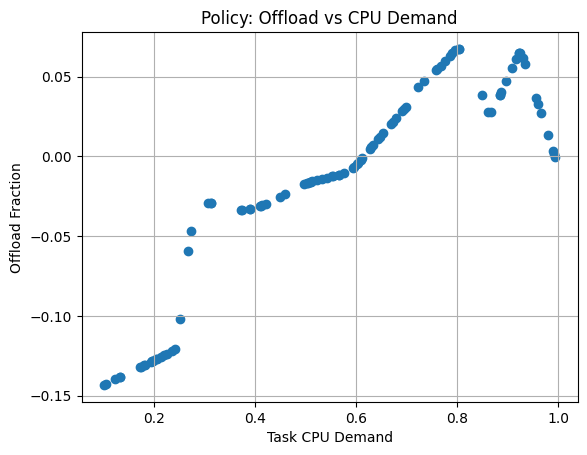

In [18]:
import matplotlib.pyplot as plt

cpu_demands = []
actions = []

obs, _ = env.reset()
for _ in range(100):
    cpu = obs['task_cpu_demand'][0]
    action, _ = model.predict(obs, deterministic=True)
    cpu_demands.append(cpu)
    actions.append(action[0])
    obs, _, _, _, _ = env.step(action)

plt.scatter(cpu_demands, actions)
plt.xlabel("Task CPU Demand")
plt.ylabel("Offload Fraction")
plt.title("Policy: Offload vs CPU Demand")
plt.grid()
plt.show()


In [4]:
if __name__ == '__main__':
    import numpy as np

    env = TaskOffloadingEnv()
    print("✅ Environment initialized.")
    print(f"Action Space: {env.action_space}")
    print(f"Observation Space: {env.observation_space}")
    print(f"Edge Device: {env.edge_device}")
    print(f"Fog Node: {env.fog_node}")
    if env.edge_device:
        print(f"Edge Device Power Model: {env.edge_device.power_model}")
    if env.fog_node:
        print(f"Fog Node Power Model: {env.fog_node.power_model}")

    print(f"Simulator tick: {env.simulator.tick_duration}")
    assert env.edge_device.power_model.idle_power_consumption == 10
    assert env.fog_node.power_model.idle_power_consumption == 50
    print("✅ Manual power model assignment correct.")

    print(f"Edge Servers: {len(EdgeServer.all())}")
    print(f"Base Stations: {len(BaseStation.all())}")
    print(f"Network Links: {len(NetworkLink.all())}")
    print(f"Network Switches: {len(NetworkSwitch.all())}")
    print(f"Container Images: {len(ContainerImage.all())}")
    print(f"Applications: {len(Application.all())}")

    assert len(EdgeServer.all()) == 2
    assert len(BaseStation.all()) == 2
    assert len(NetworkLink.all()) == 1
    assert len(NetworkSwitch.all()) == 1
    assert len(ContainerImage.all()) == 1
    assert len(Application.all()) == 1
    print("✅ Dataset loading confirmed.")

    env.render()
    print("✅ Environment rendered.")

    print("\n🔁 Testing reset method...")
    obs, info = env.reset()
    print(f"Initial observation: {obs}")
    print(f"Info: {info}")
    assert env.current_step_in_episode == 0
    assert "edge_cpu_load" in obs
    assert "fog_cpu_load" in obs
    assert "task_cpu_demand" in obs
    assert "network_latency_to_fog" in obs
    assert obs["edge_cpu_load"][0] == 0
    assert obs["fog_cpu_load"][0] == 0
    assert (50 / env.max_task_cpu_demand) <= obs["task_cpu_demand"][0] <= 1.0
    assert obs["network_latency_to_fog"][0] == (5 / env.max_network_latency)
    assert env.current_task is not None
    assert env.current_task.application == env.application
    assert env.simulator.schedule.steps == 0
    assert env.simulator.schedule.time == 0
    assert len(Service.all()) == 1
    print("✅ Reset method test passed.")

    print("\n🔁 Testing step method (edge only)...")
    action_edge = np.array([-1.0], dtype=np.float32)  # 100% local
    next_obs, reward, terminated, truncated, info = env.step(action_edge)
    print(f"Observation: {next_obs}\nReward: {reward}\nInfo: {info}")
    assert env.current_step_in_episode == 1
    assert np.isclose(info['offload_fraction'], 0.0)
    print("✅ Step (edge-only) test passed.")

    print("\n🔁 Testing step method (fog only)...")
    action_fog = np.array([1.0], dtype=np.float32)  # 100% fog
    next_obs, reward, terminated, truncated, info = env.step(action_fog)
    print(f"Observation: {next_obs}\nReward: {reward}\nInfo: {info}")
    assert env.current_step_in_episode == 2
    assert np.isclose(info['offload_fraction'], 1.0)
    print("✅ Step (fog-only) test passed.")

    print("\n🔁 Testing step method (partial offloading)...")
    action_partial = np.array([0.0], dtype=np.float32)  # 50% fog, 50% edge
    next_obs, reward, terminated, truncated, info = env.step(action_partial)
    print(f"Observation: {next_obs}\nReward: {reward}\nOffload Fraction: {info['offload_fraction']}")
    assert 0.45 <= info['offload_fraction'] <= 0.55
    print("✅ Step (partial-offload) test passed.")

    print("\n🔁 Testing truncation...")
    env.max_steps_per_episode = 2
    env.reset()
    env.step(action_edge)  # Step 1
    next_obs, reward, terminated, truncated, info = env.step(action_edge)  # Step 2
    assert truncated
    print("✅ Truncation logic works as expected.")


✅ Environment initialized.
Action Space: Box(-1.0, 1.0, (1,), float32)
Observation Space: Dict('edge_cpu_load': Box(0.0, 1.0, (1,), float32), 'fog_cpu_load': Box(0.0, 1.0, (1,), float32), 'network_latency_to_fog': Box(0.0, 1.0, (1,), float32), 'task_cpu_demand': Box(0.0, 1.0, (1,), float32))
Edge Device: EdgeServer_1
Fog Node: EdgeServer_2
Edge Device Power Model: <edge_sim_py.components.power_models.servers.linear_server_power_model.LinearServerPowerModel object at 0x7f8440106990>
Fog Node Power Model: <edge_sim_py.components.power_models.servers.linear_server_power_model.LinearServerPowerModel object at 0x7f840cf05210>
Simulator tick: 0.001
✅ Manual power model assignment correct.
Edge Servers: 2
Base Stations: 2
Network Links: 1
Network Switches: 1
Container Images: 1
Applications: 1
✅ Dataset loading confirmed.
Step: 0, Edge Load: 0, Fog Load: 0
✅ Environment rendered.

🔁 Testing reset method...
initial observation (edge_cpu_load will be 0):  [0.]
Initial observation: {'edge_cpu_lo